## 1. Import Libraries và Cấu hình

In [17]:
import pandas as pd
import numpy as np
import sys
import re
import os
import time
from itertools import combinations
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ML Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# NLP & Graph
from rapidfuzz import process, fuzz
from neo4j import GraphDatabase
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from langchain_huggingface import HuggingFacePipeline

# --- CẤU HÌNH ---
NEO4J_URI = "neo4j://localhost:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "123456789"
MODEL_ID = "Qwen/Qwen3-0.6B"
MAX_ITERATIONS = 3  # Giảm xuống để đánh giá nhanh hơn

# File paths
INPUT_CSV = "eval_level2_1000.csv"
OUTPUT_CSV = "eval_level2_results.csv"
CHECKPOINT_CSV = "eval_level2_checkpoint.csv"  # File lưu tiến trình

# Sampling (đặt None để chạy toàn bộ)
SAMPLE_SIZE = 600  # None = chạy toàn bộ dataset
START_INDEX = 0     # Bắt đầu từ index nào (tự động skip nếu có checkpoint)

print("✅ Import thành công!")
print(f"📌 Model: {MODEL_ID}")
print(f"📌 Dataset: {INPUT_CSV}")
print(f"📌 Checkpoint: {CHECKPOINT_CSV}")

✅ Import thành công!
📌 Model: Qwen/Qwen3-0.6B
📌 Dataset: eval_level2_1000.csv
📌 Checkpoint: eval_level2_checkpoint.csv


## 2. Khởi tạo Hệ thống (LLM + Neo4j)

In [18]:
def init_system():
    """Khởi tạo LLM, tokenizer, Neo4j driver và danh sách thực thể"""
    print("⏳ Đang khởi tạo hệ thống...")
    
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype="auto", device_map="auto")
    
    # Temperature thấp để đánh giá chính xác hơn
    pipe = pipeline(
        "text-generation", model=model, tokenizer=tokenizer,
        max_new_tokens=32768, temperature=0.3, top_p=0.95, top_k=20, 
        repetition_penalty=1.1,
    )
    llm = HuggingFacePipeline(pipeline=pipe)
    driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
    
    # Load entity names for normalization
    print("⏳ Đang tải danh sách thực thể từ Neo4j...")
    all_names = []
    try:
        with driver.session() as session:
            result = session.run("MATCH (n) WHERE n.name IS NOT NULL RETURN DISTINCT n.name as name")
            all_names = [r["name"] for r in result]
        print(f"✅ Đã tải {len(all_names)} tên thực thể.")
    except Exception as e:
        print(f"⚠️ Lỗi: {e}")

    print("✅ Hệ thống sẵn sàng!")
    return llm, tokenizer, driver, all_names

# Khởi tạo
llm, tokenizer, driver, all_names = init_system()

⏳ Đang khởi tạo hệ thống...


Device set to use cuda:0


⏳ Đang tải danh sách thực thể từ Neo4j...
✅ Đã tải 5787 tên thực thể.
✅ Hệ thống sẵn sàng!


## 3. Định nghĩa các hàm trích xuất thực thể và xử lý

In [19]:
def parse_qwen3_output(text):
    """Loại bỏ phần thinking của Qwen3"""
    if "<think>" in text: 
        text = text.split("</think>")[-1]
    return text.strip()

def clean_entities(raw_text, source_text):
    """Làm sạch danh sách thực thể trích xuất"""
    candidates = [e.strip() for e in raw_text.split(',') if e.strip()]
    candidates = [e.replace(".", "").replace('"', '').replace("'", "") for e in candidates]
    valid = [c for c in candidates if len(c) > 2]
    return valid

def normalize_entities(entities, all_names, threshold=85):
    """Chuẩn hóa tên thực thể bằng RapidFuzz"""
    if not all_names: 
        return entities
    
    normalized = []
    for entity in entities:
        match = process.extractOne(entity, all_names, scorer=fuzz.WRatio)
        if match:
            best_name, score, _ = match
            if score >= threshold:
                normalized.append(best_name)
            # Loại bỏ nếu điểm thấp
    return list(set(normalized))

def extract_initial_entities(question):
    """Vòng 1: Trích xuất thực thể từ câu hỏi gốc"""
    examples = """
    Hỏi: Brad Pitt và Leonardo DiCaprio có cùng đóng phim Titanic không? -> Thực thể: Brad Pitt, Leonardo DiCaprio, Titanic
    Hỏi: Tom Hanks có phải là đạo diễn của bộ phim Forrest Gump không? -> Thực thể: Tom Hanks, Forrest Gump
    Hỏi: John và Mary có phải là anh em không? -> Thực thể: John, Mary
    """
    messages = [
        {"role": "system", "content": "Trích xuất TẤT CẢ các TÊN RIÊNG (Người, Phim) từ câu hỏi. Ngăn cách bởi dấu phẩy. Không thêm từ thừa."},
        {"role": "user", "content": f"Ví dụ:{examples}\n\nCâu hỏi: {question}\nThực thể:"}
    ]
    
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=True)
    res = llm.invoke(prompt)
    if prompt in res: 
        res = res.replace(prompt, "")
    
    raw = parse_qwen3_output(res).split('\n')[0].replace("Thực thể:", "").strip()
    return clean_entities(raw, question)

def extract_more_entities(question, current_context):
    """Vòng >1: Trích xuất thêm thực thể từ ngữ cảnh đã tìm được"""
    system_msg = """Bạn là trợ lý suy luận. 
    Dựa vào CÂU HỎI và THÔNG TIN ĐÃ BIẾT, hãy xác định xem cần tìm kiếm thêm thông tin về NHÂN VẬT hoặc BỘ PHIM nào nữa.
    Chỉ liệt kê tên riêng mới. Nếu không cần thêm, trả về 'NONE'."""
    
    user_msg = f"""CÂU HỎI: {question}
    THÔNG TIN ĐÃ BIẾT:
    {current_context}
    
    Cần tìm thêm thông tin về ai (Tên riêng)?"""
    
    messages = [{"role": "system", "content": system_msg}, {"role": "user", "content": user_msg}]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=True)
    res = llm.invoke(prompt)
    if prompt in res: 
        res = res.replace(prompt, "")
    
    raw = parse_qwen3_output(res)
    
    if "NONE" in raw or "không cần" in raw.lower():
        return []
    
    return clean_entities(raw, raw)

def check_sufficiency(question, context):
    """Kiểm tra xem thông tin đã đủ để trả lời chưa"""
    if not context: 
        return False, "Chưa có thông tin."
    
    messages = [
        {"role": "system", "content": "Bạn là giám khảo khắt khe. Đánh giá xem thông tin đã ĐỦ để trả lời câu hỏi chưa. Chỉ trả lời 'ĐỦ' hoặc 'CHƯA ĐỦ'."},
        {"role": "user", "content": f"CÂU HỎI: {question}\nTHÔNG TIN:\n{context}\n\nĐánh giá:"}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    res = llm.invoke(prompt)
    if prompt in res: 
        res = res.replace(prompt, "")
    
    answer = parse_qwen3_output(res).lower()
    is_sufficient = "đủ" in answer and "chưa" not in answer
    return is_sufficient, answer

print("✅ Định nghĩa các hàm trích xuất thực thể thành công!")

✅ Định nghĩa các hàm trích xuất thực thể thành công!


## 4. Định nghĩa các hàm truy vấn đồ thị Neo4j

In [20]:
def find_node_qid(session, name):
    """Tìm QID của node theo tên (fuzzy search)"""
    result = session.run(
        "CALL db.index.fulltext.queryNodes('names', $name + '~') YIELD node, score "
        "RETURN node.name, node.qid, labels(node) ORDER BY score DESC LIMIT 1", 
        name=name
    ).single()
    if result: 
        return {"name": result[0], "qid": result[1], "labels": result[2]}
    return None

def get_node_details_text(session, qid, name):
    """Lấy thông tin chi tiết của node"""
    node = session.run("MATCH (n {qid: $qid}) RETURN n.gender, n.birthDate", qid=qid).single()
    if not node: 
        return ""
    info = [f"**{name}:**"]
    if node[0]: 
        info.append(f"Giới tính: {node[0]}")
    if node[1]: 
        info.append(f"Sinh: {str(node[1]).split('T')[0]}")
    return " - ".join(info)

def get_relationship_action(rel_type, is_forward):
    """Map relationship type to Vietnamese text"""
    mapping = {
        "ACTED_IN": ("đóng trong phim", "có diễn viên là"),
        "DIRECTED": ("là đạo diễn của", "được đạo diễn bởi"),
        "PRODUCED": ("sản xuất phim", "được sản xuất bởi"),
        "IS_CHILD_OF": ("là con của", "là cha/mẹ của"),
        "IS_CHILD_OF_DAD": ("là con của cha", "là cha của"),
        "IS_CHILD_OF_MOM": ("là con của mẹ", "là mẹ của"),
        "IS_PARENT_OF": ("là cha/mẹ của", "là con của"),
        "IS_SPOUSE_OF": ("là vợ/chồng của", "là vợ/chồng của"),
        "IS_PARTNER_OF": ("là bạn đời của", "là bạn đời của"),
        "IS_SIBLING_OF": ("là anh/chị em với", "là anh/chị em với"),
        "HAS_GRANDPARENT_OF": ("là cháu của", "là ông/bà của"),
    }
    if rel_type in mapping:
        return mapping[rel_type][0 if is_forward else 1]
    return f"có quan hệ {rel_type} với"

def format_path_text(path):
    """Format đường đi ngữ nghĩa"""
    nodes = path.nodes
    rels = path.relationships
    parts = []
    
    for i, rel in enumerate(rels):
        start = nodes[i]
        end = nodes[i+1]
        is_forward = (rel.start_node.element_id == start.element_id)
        action = get_relationship_action(rel.type, is_forward)
        parts.append(f"{start['name']} {action} {end['name']}")
        
    return " -> ".join(parts) + "."

def get_full_graph_context(entity_names):
    """Truy xuất context đầy đủ từ đồ thị (Full Mesh)"""
    with driver.session() as session:
        nodes = []
        for name in entity_names:
            n = find_node_qid(session, name)
            if n: 
                nodes.append(n)
        
        if not nodes: 
            return "Không tìm thấy node nào trong cơ sở dữ liệu."
        
        context_parts = []
        
        # 1. Thông tin chi tiết
        context_parts.append("--- THÔNG TIN CÁ NHÂN ---")
        for n in nodes:
            details = get_node_details_text(session, n['qid'], n['name'])
            if details:
                context_parts.append(details)
            
        # 2. Quan hệ (Full Mesh)
        context_parts.append("\n--- MỐI QUAN HỆ ---")
        
        for n in nodes:
            res = session.run(
                "MATCH (n {qid: $id})-[r]-(m) RETURN r, n, m LIMIT 50", 
                id=n['qid']
            )
            
            has_rel = False
            for record in res:
                r = record['r']
                n_node = record['n']
                m_node = record['m']
                
                is_forward = (r.start_node.element_id == n_node.element_id)
                action = get_relationship_action(r.type, is_forward)
                context_parts.append(f"{n_node['name']} {action} {m_node['name']}")
                has_rel = True
            
            if not has_rel:
                context_parts.append(f"{n['name']} không có quan hệ nào trong DB.")

        # 3. Tìm đường giữa các cặp
        if len(nodes) >= 2:
            context_parts.append("\n--- LIÊN KẾT GIỮA CÁC THỰC THỂ ---")
            pairs = list(combinations(nodes, 2))
            
            for start, end in pairs:
                query = """
                    MATCH (p1 {qid: $s}), (p2 {qid: $e})
                    MATCH path = shortestPath((p1)-[*..6]-(p2))
                    RETURN path
                """
                result = session.run(query, s=start['qid'], e=end['qid']).single()
                
                if result:
                    path_text = format_path_text(result['path'])
                    context_parts.append(f"✓ Liên kết {start['name']} - {end['name']}: {path_text}")
                else:
                    context_parts.append(f"✗ KHÔNG tìm thấy liên kết giữa {start['name']} và {end['name']}.")
                    
        return "\n".join(context_parts)

print("✅ Định nghĩa hàm truy vấn đồ thị thành công!")

✅ Định nghĩa hàm truy vấn đồ thị thành công!


## 5. Định nghĩa hàm trả lời câu hỏi Đúng/Sai và đánh giá

In [21]:
def generate_true_false_answer(question, context):
    """
    Sinh câu trả lời Đúng/Sai dựa trên context.
    Yêu cầu bot phân tích và trả lời rõ ràng A (Đúng) hoặc B (Sai).
    """
    system_prompt = """Bạn là chuyên gia phân tích dữ liệu về điện ảnh và người nổi tiếng.
Dựa vào DỮ LIỆU được cung cấp, hãy xác định mệnh đề trong câu hỏi là ĐÚNG hay SAI.

QUY TẮC QUAN TRỌNG:
1. Nếu DỮ LIỆU xác nhận mệnh đề đúng → Trả lời A (Đúng)
2. Nếu DỮ LIỆU cho thấy mệnh đề sai hoặc KHÔNG có bằng chứng → Trả lời B (Sai)
3. Nếu không tìm thấy liên kết hoặc thiếu thông tin → Trả lời B (Sai)

Trả lời theo format: "Đáp án: [A/B]. Lý do: [giải thích ngắn gọn]"
"""
    
    user_prompt = f"""DỮ LIỆU:
{context}

CÂU HỎI: {question}

A) Đúng
B) Sai

Phân tích dữ liệu và chọn đáp án:"""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=True)
    res = llm.invoke(prompt)
    if prompt in res: 
        res = res.replace(prompt, "")
    return parse_qwen3_output(res)


def solve_question_iterative_level2(question):
    """
    Pipeline ITERATIVE cho câu hỏi Level 2 (Đúng/Sai)
    """
    accumulated_entities = set()
    current_context = ""
    
    for i in range(MAX_ITERATIONS):
        # BƯỚC 1: TRÍCH XUẤT
        new_entities = []
        if i == 0:
            new_entities = extract_initial_entities(question)
        else:
            new_entities = extract_more_entities(question, current_context)
        
        # BƯỚC 2: CHUẨN HÓA
        new_entities = normalize_entities(new_entities, all_names)
        
        # Cập nhật danh sách thực thể
        prev_len = len(accumulated_entities)
        for e in new_entities:
            accumulated_entities.add(e)
        
        # Nếu không tìm thêm được thực thể mới -> Dừng
        if len(accumulated_entities) == prev_len and i > 0:
            break
            
        if not accumulated_entities:
            return "Không tìm thấy thực thể", ""
            
        # BƯỚC 3: TRUY XUẤT GRAPH
        current_context = get_full_graph_context(list(accumulated_entities))
        
        # BƯỚC 4: KIỂM TRA ĐỘ ĐẦY ĐỦ
        is_enough, _ = check_sufficiency(question, current_context)
        
        if is_enough:
            break
    
    # BƯỚC 5: SINH CÂU TRẢ LỜI (Đúng/Sai)
    answer = generate_true_false_answer(question, current_context)
    
    return answer, current_context


def evaluate_true_false_answer(bot_answer, ground_truth_letter):
    """
    Đánh giá câu trả lời Đúng/Sai của bot.
    
    Args:
        bot_answer: Câu trả lời của bot
        ground_truth_letter: "A" (Đúng) hoặc "B" (Sai)
    
    Returns: 1 nếu đúng, 0 nếu sai
    """
    bot_ans_lower = bot_answer.lower()
    
    # Xác định bot chọn A hay B
    bot_choice = None
    
    # Pattern cho đáp án A (Đúng)
    patterns_a = [
        "đáp án: a", "đáp án a", "chọn a", "là a)", "là a.",
        "→ a", "=> a", ": a.", ": a)", "[a]",
        "đáp án là a", "trả lời: a", "answer: a",
        "đúng", "có", "phải", "chính xác", "xác nhận"
    ]
    
    # Pattern cho đáp án B (Sai)
    patterns_b = [
        "đáp án: b", "đáp án b", "chọn b", "là b)", "là b.",
        "→ b", "=> b", ": b.", ": b)", "[b]",
        "đáp án là b", "trả lời: b", "answer: b",
        "sai", "không", "không phải", "không đúng", "không có"
    ]
    
    # Ưu tiên check pattern A/B rõ ràng trước
    for pattern in ["đáp án: a", "đáp án a", "chọn a", "[a]", ": a."]:
        if pattern in bot_ans_lower:
            bot_choice = "A"
            break
    
    if bot_choice is None:
        for pattern in ["đáp án: b", "đáp án b", "chọn b", "[b]", ": b."]:
            if pattern in bot_ans_lower:
                bot_choice = "B"
                break
    
    # Nếu chưa xác định, check keyword
    if bot_choice is None:
        # Đếm keyword
        a_score = sum(1 for p in ["đúng", "có", "phải", "chính xác"] if p in bot_ans_lower)
        b_score = sum(1 for p in ["sai", "không phải", "không đúng", "không có", "không tìm thấy"] if p in bot_ans_lower)
        
        # Check "không" đơn lẻ (cẩn thận với "không" trong ngữ cảnh khác)
        if "không" in bot_ans_lower and "không có liên" in bot_ans_lower:
            b_score += 2
        
        if a_score > b_score:
            bot_choice = "A"
        elif b_score > a_score:
            bot_choice = "B"
        else:
            bot_choice = "B"  # Default: Sai (conservative)
    
    # So sánh với ground truth
    return 1 if bot_choice == ground_truth_letter else 0


print("✅ Định nghĩa hàm trả lời Đúng/Sai cho Level 2 thành công!")

✅ Định nghĩa hàm trả lời Đúng/Sai cho Level 2 thành công!


## 6. Load Dataset

In [22]:
# Load dataset
df = pd.read_csv(INPUT_CSV)
print(f"📊 Đã tải {len(df)} câu hỏi từ {INPUT_CSV}")
print(f"\n📋 Phân bố theo loại quan hệ:")
print(df['rel_type'].value_counts())

print(f"\n📋 Phân bố đáp án:")
print(df['answer'].value_counts())

# Preview
df.head()

📊 Đã tải 1000 câu hỏi từ eval_level2_1000.csv

📋 Phân bố theo loại quan hệ:
rel_type
CO_ACTOR          401
CONNECTION        154
TRIPLE_LINK       147
DIRECTOR_ACTOR    144
IS_SPOUSE_OF       52
IS_SIBLING_OF      52
IS_CHILD_OF        50
Name: count, dtype: int64

📋 Phân bố đáp án:
answer
B    630
A    370
Name: count, dtype: int64


,level,rel_type,question,option_a,option_b,answer,ground_truth
0,2,CONNECTION,John Lynch và Emma Bloomberg có quen biết hoặc...,Đúng,Sai,B,"Sai (hoặc Không), không tìm thấy mối liên hệ g..."
1,2,CO_ACTOR,David Lynch và Matt Damon có cùng tham gia vào...,Đúng,Sai,B,"Sai, David Lynch không tham gia phim 'The Depa..."
2,2,CO_ACTOR,David Lynch và Donald Trump có cùng tham gia v...,Đúng,Sai,B,"Sai, David Lynch không tham gia phim 'BlacKkKl..."
3,2,CO_ACTOR,David Lynch và Al Pacino có cùng tham gia vào ...,Đúng,Sai,B,"Sai, David Lynch không tham gia phim 'Dog Day ..."
4,2,IS_SPOUSE_OF,Bruce Lee có phải là vợ/chồng của Linda Lee Ca...,Đúng,Sai,A,"Đúng, Bruce Lee là vợ/chồng của Linda Lee Cadw..."


In [23]:
# Lấy dữ liệu TUẦN TỰ (không random) để dễ resume
if SAMPLE_SIZE:
    df_eval = df.iloc[START_INDEX:START_INDEX + SAMPLE_SIZE].reset_index(drop=True)
    print(f"⚠️ Chạy trên {len(df_eval)} câu hỏi (từ index {START_INDEX} đến {START_INDEX + SAMPLE_SIZE - 1})")
else:
    df_eval = df.iloc[START_INDEX:].reset_index(drop=True)
    print(f"🚀 Chạy đánh giá trên {len(df_eval)} câu hỏi (từ index {START_INDEX})")

# AUTO RESUME: Tự động tiếp tục từ checkpoint nếu có
if os.path.exists(CHECKPOINT_CSV):
    checkpoint_df = pd.read_csv(CHECKPOINT_CSV)
    print(f"\n💾 Tìm thấy checkpoint với {len(checkpoint_df)} kết quả đã lưu")
    print("🔄 Tự động tiếp tục từ checkpoint...")
    resume = True
else:
    checkpoint_df = None
    resume = False
    print("\n🆕 Bắt đầu mới từ đầu...")

⚠️ Chạy trên 600 câu hỏi (từ index 0 đến 599)

💾 Tìm thấy checkpoint với 10 kết quả đã lưu
🔄 Tự động tiếp tục từ checkpoint...


## 7. Chạy Đánh giá

In [ ]:
# === HOÀN TOÀN TỰ ĐỘNG - KHÔNG CẦN CAN THIỆP ===

# Khởi tạo hoặc load từ checkpoint
if resume and checkpoint_df is not None:
    results = checkpoint_df.to_dict('records')
    start_idx = len(results)
    print(f"📂 Tự động resume từ câu hỏi thứ {start_idx + 1}/{len(df_eval)}")
else:
    results = []
    start_idx = 0

# Cho metrics
y_true = [r['ground_truth_label'] for r in results] if results else []
y_pred = [r['score'] for r in results] if results else []

# Thời gian bắt đầu
start_time = time.time()
CHECKPOINT_INTERVAL = 10  # Lưu checkpoint sau mỗi 10 câu

print(f"\n{'='*60}")
print(f"🚀 BẮT ĐẦU ĐÁNH GIÁ ITERATIVE GRAPH RAG - LEVEL 2")
print(f"{'='*60}")
print(f"📋 Từ câu {start_idx + 1} đến câu {len(df_eval)}")
print(f"📋 Loại câu hỏi: Đúng/Sai (True/False)")
print(f"📋 Checkpoint tự động lưu sau mỗi {CHECKPOINT_INTERVAL} câu")
print(f"{'='*60}\n")

# === VÒNG LẶP ĐÁNH GIÁ CHÍNH ===
for idx in tqdm(range(start_idx, len(df_eval)), desc="Đánh giá Level 2", initial=start_idx, total=len(df_eval)):
    row = df_eval.iloc[idx]
    question = row['question']
    ground_truth_letter = row['answer']  # "A" hoặc "B"
    ground_truth_text = row['ground_truth']  # Giải thích
    rel_type = row['rel_type']
    
    # Label: A = 1 (Đúng), B = 0 (Sai)
    ground_truth_label = 1 if ground_truth_letter == "A" else 0
    
    try:
        # Chạy pipeline ITERATIVE
        bot_answer, context = solve_question_iterative_level2(question)
        
        # Đánh giá
        score = evaluate_true_false_answer(bot_answer, ground_truth_letter)
        
    except Exception as e:
        bot_answer = f"Error: {str(e)}"
        context = ""
        score = 0
        print(f"\n❌ Lỗi câu {idx + 1}: {e}")
    
    # Lưu kết quả
    results.append({
        "question": question,
        "ground_truth_letter": ground_truth_letter,
        "ground_truth_text": ground_truth_text,
        "ground_truth_label": ground_truth_label,
        "bot_answer": bot_answer[:500] if bot_answer else "",
        "rel_type": rel_type,
        "score": score,
        "context_length": len(context) if context else 0
    })
    
    # Cho metrics
    y_true.append(ground_truth_label)
    y_pred.append(score)
    
    # Lưu checkpoint định kỳ
    if (idx + 1) % CHECKPOINT_INTERVAL == 0:
        pd.DataFrame(results).to_csv(CHECKPOINT_CSV, index=False, encoding='utf-8-sig')
        correct_so_far = sum(r['score'] for r in results)
        acc_so_far = correct_so_far / len(results) * 100
        elapsed = time.time() - start_time
        print(f"\n💾 Checkpoint: {len(results)} câu | Accuracy: {acc_so_far:.1f}% | Time: {elapsed/60:.1f}m")

# Lưu checkpoint cuối cùng
pd.DataFrame(results).to_csv(CHECKPOINT_CSV, index=False, encoding='utf-8-sig')

# Tổng kết
total_time = time.time() - start_time
print(f"\n{'='*60}")
print(f"🎉 HOÀN THÀNH ĐÁNH GIÁ LEVEL 2!")
print(f"{'='*60}")
print(f"✅ Tổng số câu: {len(results)}")
print(f"⏱️ Tổng thời gian: {total_time/60:.1f} phút ({total_time/3600:.2f} giờ)")
print(f"💾 Đã lưu vào: {CHECKPOINT_CSV}")

📂 Tự động resume từ câu hỏi thứ 11/600

🚀 BẮT ĐẦU ĐÁNH GIÁ ITERATIVE GRAPH RAG - LEVEL 2
📋 Từ câu 11 đến câu 600
📋 Loại câu hỏi: Đúng/Sai (True/False)
📋 Checkpoint tự động lưu sau mỗi 10 câu



Đánh giá Level 2:   2%|▏         | 10/600 [00:00<?, ?it/s]

Đánh giá Level 2:   3%|▎         | 20/600 [01:26<1:15:57,  7.86s/it]


💾 Checkpoint: 20 câu | Accuracy: 65.0% | Time: 1.4m


Đánh giá Level 2:   5%|▌         | 30/600 [03:17<1:51:59, 11.79s/it]

...

Đánh giá Level 2:  53%|█████▎    | 320/600 [51:43<46:30,  9.96s/it]


💾 Checkpoint: 320 câu | Accuracy: 62.2% | Time: 51.7m


Đánh giá Level 2:  55%|█████▌    | 330/600 [53:11<40:43,  9.05s/it]


💾 Checkpoint: 330 câu | Accuracy: 62.1% | Time: 53.2m


Đánh giá Level 2:  55%|█████▌    | 331/600 [53:27<50:26, 11.25s/it]

## 8. Tính toán và Hiển thị Metrics

In [ ]:
# Chuyển kết quả sang DataFrame
results_df = pd.DataFrame(results)

# === TÍNH TOÁN METRICS ===
total = len(results_df)
correct = results_df['score'].sum()

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Precision, Recall, F1 (binary)
# positive class = 1 (trả lời đúng)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

# === HIỂN THỊ KẾT QUẢ ===
print("=" * 60)
print("📊 KẾT QUẢ ĐÁNH GIÁ ITERATIVE GRAPH RAG - LEVEL 2")
print("=" * 60)
print(f"📁 Dataset: {INPUT_CSV}")
print(f"📝 Tổng số câu hỏi: {total}")
print(f"✅ Số câu đúng: {correct}")
print(f"❌ Số câu sai: {total - correct}")
print("-" * 60)
print(f"🎯 ACCURACY:  {accuracy * 100:.2f}%")
print(f"📐 PRECISION: {precision * 100:.2f}%")
print(f"📏 RECALL:    {recall * 100:.2f}%")
print(f"⚖️  F1-SCORE:  {f1 * 100:.2f}%")
print("=" * 60)

# Tạo summary DataFrame
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [f"{accuracy*100:.2f}%", f"{precision*100:.2f}%", f"{recall*100:.2f}%", f"{f1*100:.2f}%"]
})
metrics_summary

📊 KẾT QUẢ ĐÁNH GIÁ ITERATIVE GRAPH RAG - LEVEL 2
📁 Dataset: eval_level2_1000.csv
📝 Tổng số câu hỏi: 10
✅ Số câu đúng: 8
❌ Số câu sai: 2
------------------------------------------------------------
🎯 ACCURACY:  80.00%
📐 PRECISION: 75.00%
📏 RECALL:    100.00%
⚖️  F1-SCORE:  85.71%


,Metric,Value
0,Accuracy,80.00%
1,Precision,75.00%
2,Recall,100.00%
3,F1-Score,85.71%


In [ ]:
# Chuyển kết quả sang DataFrame
results_df = pd.DataFrame(results)

# === TÍNH TOÁN METRICS ===
total = len(results_df)
correct = results_df['score'].sum()

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Precision, Recall, F1 (binary)
# positive class = 1 (trả lời đúng)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

# === HIỂN THỊ KẾT QUẢ ===
print("=" * 60)
print("📊 KẾT QUẢ ĐÁNH GIÁ ITERATIVE GRAPH RAG - LEVEL 2")
print("=" * 60)
print(f"📁 Dataset: {INPUT_CSV}")
print(f"📝 Tổng số câu hỏi: {total}")
print(f"✅ Số câu đúng: {correct}")
print(f"❌ Số câu sai: {total - correct}")
print("-" * 60)
print(f"🎯 ACCURACY:  {accuracy * 100:.2f}%")
print(f"📐 PRECISION: {precision * 100:.2f}%")
print(f"📏 RECALL:    {recall * 100:.2f}%")
print(f"⚖️  F1-SCORE:  {f1 * 100:.2f}%")
print("=" * 60)

# Tạo summary DataFrame
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [f"{accuracy*100:.2f}%", f"{precision*100:.2f}%", f"{recall*100:.2f}%", f"{f1*100:.2f}%"]
})
metrics_summary

📊 KẾT QUẢ ĐÁNH GIÁ ITERATIVE GRAPH RAG - LEVEL 2
📁 Dataset: eval_level2_1000.csv
📝 Tổng số câu hỏi: 10
✅ Số câu đúng: 8
❌ Số câu sai: 2
------------------------------------------------------------
🎯 ACCURACY:  80.00%
📐 PRECISION: 75.00%
📏 RECALL:    100.00%
⚖️  F1-SCORE:  85.71%


,Metric,Value
0,Accuracy,80.00%
1,Precision,75.00%
2,Recall,100.00%
3,F1-Score,85.71%


In [ ]:
# Chuyển kết quả sang DataFrame
results_df = pd.DataFrame(results)

# === TÍNH TOÁN METRICS ===
total = len(results_df)
correct = results_df['score'].sum()

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Precision, Recall, F1 (binary)
# positive class = 1 (trả lời đúng)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

# === HIỂN THỊ KẾT QUẢ ===
print("=" * 60)
print("📊 KẾT QUẢ ĐÁNH GIÁ ITERATIVE GRAPH RAG - LEVEL 2")
print("=" * 60)
print(f"📁 Dataset: {INPUT_CSV}")
print(f"📝 Tổng số câu hỏi: {total}")
print(f"✅ Số câu đúng: {correct}")
print(f"❌ Số câu sai: {total - correct}")
print("-" * 60)
print(f"🎯 ACCURACY:  {accuracy * 100:.2f}%")
print(f"📐 PRECISION: {precision * 100:.2f}%")
print(f"📏 RECALL:    {recall * 100:.2f}%")
print(f"⚖️  F1-SCORE:  {f1 * 100:.2f}%")
print("=" * 60)

# Tạo summary DataFrame
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [f"{accuracy*100:.2f}%", f"{precision*100:.2f}%", f"{recall*100:.2f}%", f"{f1*100:.2f}%"]
})
metrics_summary

📊 KẾT QUẢ ĐÁNH GIÁ ITERATIVE GRAPH RAG - LEVEL 2
📁 Dataset: eval_level2_1000.csv
📝 Tổng số câu hỏi: 10
✅ Số câu đúng: 8
❌ Số câu sai: 2
------------------------------------------------------------
🎯 ACCURACY:  80.00%
📐 PRECISION: 75.00%
📏 RECALL:    100.00%
⚖️  F1-SCORE:  85.71%


,Metric,Value
0,Accuracy,80.00%
1,Precision,75.00%
2,Recall,100.00%
3,F1-Score,85.71%


## 9. Phân tích theo Loại Quan hệ

In [ ]:
# Tính accuracy theo từng loại quan hệ
rel_stats = results_df.groupby('rel_type').agg({
    'score': ['sum', 'count', 'mean']
}).round(4)
rel_stats.columns = ['Correct', 'Total', 'Accuracy']
rel_stats['Accuracy'] = (rel_stats['Accuracy'] * 100).round(2)
rel_stats = rel_stats.sort_values('Accuracy', ascending=False)

print("📊 ACCURACY THEO LOẠI QUAN HỆ (LEVEL 2):")
print("-" * 50)
rel_stats

📊 ACCURACY THEO LOẠI QUAN HỆ (LEVEL 2):
--------------------------------------------------


,Correct,Total,Accuracy
rel_type,,,
CONNECTION,2,2,100.0
DIRECTOR_ACTOR,1,1,100.0
IS_SPOUSE_OF,1,1,100.0
TRIPLE_LINK,1,1,100.0
CO_ACTOR,3,5,60.0


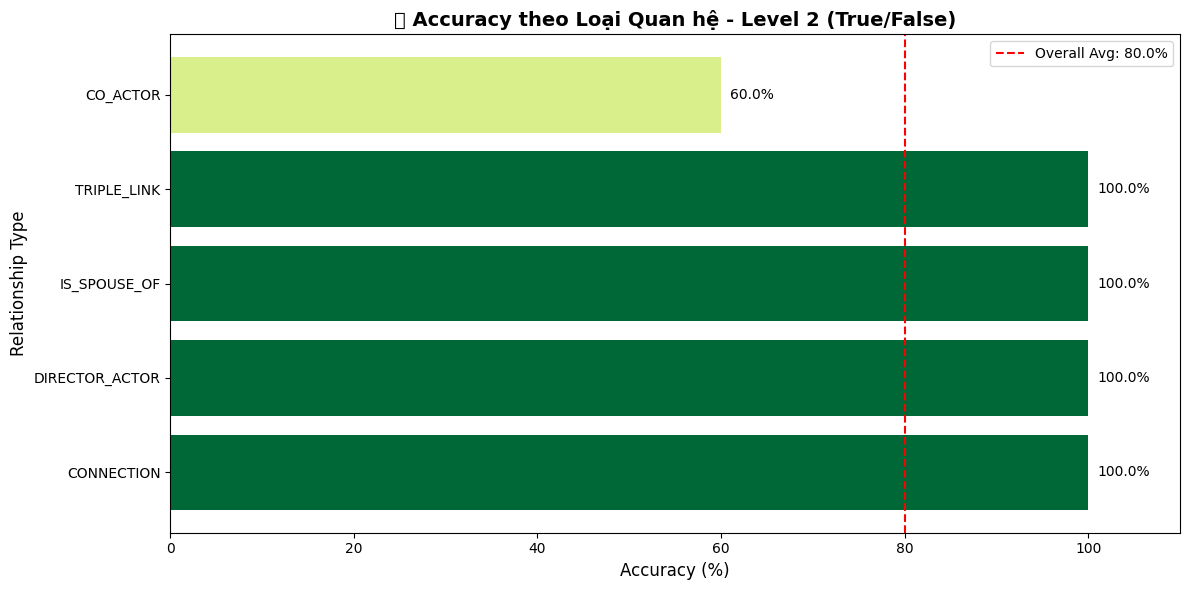

In [ ]:
# Vẽ biểu đồ Accuracy theo loại quan hệ
fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.RdYlGn(rel_stats['Accuracy'] / 100)
bars = ax.barh(rel_stats.index, rel_stats['Accuracy'], color=colors)

# Thêm label trên mỗi bar
for bar, acc in zip(bars, rel_stats['Accuracy']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{acc:.1f}%', va='center', fontsize=10)

ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_ylabel('Relationship Type', fontsize=12)
ax.set_title('📊 Accuracy theo Loại Quan hệ - Level 2 (True/False)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 110)
ax.axvline(x=accuracy*100, color='red', linestyle='--', label=f'Overall Avg: {accuracy*100:.1f}%')
ax.legend()

plt.tight_layout()
plt.savefig('iterative_level2_accuracy_by_reltype.png', dpi=150)
plt.show()

## 10. Phân tích theo Đáp án Ground Truth (A vs B)

In [ ]:
# Phân tích accuracy theo đáp án ground truth
answer_stats = results_df.groupby('ground_truth_letter').agg({
    'score': ['sum', 'count', 'mean']
}).round(4)
answer_stats.columns = ['Correct', 'Total', 'Accuracy']
answer_stats['Accuracy'] = (answer_stats['Accuracy'] * 100).round(2)

print("📊 ACCURACY THEO ĐÁP ÁN GROUND TRUTH:")
print("-" * 50)
print("A = Đúng (True), B = Sai (False)")
print("-" * 50)
answer_stats

📊 ACCURACY THEO ĐÁP ÁN GROUND TRUTH:
--------------------------------------------------
A = Đúng (True), B = Sai (False)
--------------------------------------------------


,Correct,Total,Accuracy
ground_truth_letter,,,
A,6,6,100.0
B,2,4,50.0


## 11. Lưu kết quả

In [ ]:
# Lưu kết quả chi tiết
results_df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
print(f"💾 Đã lưu kết quả chi tiết vào: {OUTPUT_CSV}")

# Lưu metrics summary
metrics_full = {
    'metric': ['accuracy', 'precision', 'recall', 'f1_score', 'total_questions', 'correct_answers'],
    'value': [accuracy, precision, recall, f1, total, correct]
}
pd.DataFrame(metrics_full).to_csv('eval_level2_metrics.csv', index=False)
print("💾 Đã lưu metrics vào: eval_level2_metrics.csv")

💾 Đã lưu kết quả chi tiết vào: eval_level2_results.csv
💾 Đã lưu metrics vào: eval_level2_metrics.csv


## 12. Phân tích một số câu trả lời

In [ ]:
# Xem một số câu đúng
print("✅ MẪU CÂU TRẢ LỜI ĐÚNG:")
print("=" * 80)
correct_samples = results_df[results_df['score'] == 1].head(3)

for idx, row in correct_samples.iterrows():
    print(f"\n📌 Câu hỏi: {row['question']}")
    print(f"   ✅ Đáp án đúng: {row['ground_truth_letter']} - {row['ground_truth_text'][:100]}...")
    print(f"   🤖 Bot trả lời: {row['bot_answer'][:200]}...")
    print("-" * 80)

✅ MẪU CÂU TRẢ LỜI ĐÚNG:

📌 Câu hỏi: John Lynch và Emma Bloomberg có quen biết hoặc liên quan gì nhau không?
   ✅ Đáp án đúng: B - Sai (hoặc Không), không tìm thấy mối liên hệ gần gũi nào giữa họ trong dữ liệu....
   🤖 Bot trả lời: Đáp án: B. Lý do: Dữ liệu cho thấy không có bằng chứng trực tiếp về mối quan hệ giữa John Lynch và Emma Bloomberg, trừ khi được liệt kê rõ ràng.  

"Liên kết giữa họ không được xác minh trong dữ liệu....
--------------------------------------------------------------------------------

📌 Câu hỏi: David Lynch và Donald Trump có cùng tham gia vào bộ phim 'BlacKkKlansman' không?
   ✅ Đáp án đúng: B - Sai, David Lynch không tham gia phim 'BlacKkKlansman'....
   🤖 Bot trả lời: Đáp án: B. Lý do: Dữ liệu không xác nhận mối quan hệ giữa David Lynch và bộ phim 'BlacKkKlansman'; dựa trên thông tin đã cung cấp, David Lynch chỉ được liệt kê như đạo diễn trong các tác phẩm khác nha...
--------------------------------------------------------------------------------

📌 Câu h

In [ ]:
# Phân tích các câu trả lời sai
wrong_answers = results_df[results_df['score'] == 0]
print(f"\n❌ PHÂN TÍCH CÂU TRẢ LỜI SAI ({len(wrong_answers)} câu):")
print("=" * 80)

# Hiển thị 5 câu sai đầu tiên
for idx, row in wrong_answers.head(5).iterrows():
    print(f"\n📌 Câu hỏi: {row['question']}")
    print(f"   ✅ Đáp án đúng: {row['ground_truth_letter']} - {row['ground_truth_text'][:100]}...")
    print(f"   ❌ Bot trả lời: {row['bot_answer'][:200]}...")
    print(f"   🏷️ Loại: {row['rel_type']}")
    print("-" * 80)


❌ PHÂN TÍCH CÂU TRẢ LỜI SAI (2 câu):

📌 Câu hỏi: David Lynch và Matt Damon có cùng tham gia vào bộ phim 'The Departed' không?
   ✅ Đáp án đúng: B - Sai, David Lynch không tham gia phim 'The Departed'....
   ❌ Bot trả lời: Đáp án: A) Đúng. Lý do: Dữ liệu xác nhận rằng cả David Lynch và Matt Damon đều tham gia vào bộ phim "The Departed", với Matt Damon đóng vai trò diễn viên và David Lynch làm đạo diễn....
   🏷️ Loại: CO_ACTOR
--------------------------------------------------------------------------------

📌 Câu hỏi: David Lynch và Al Pacino có cùng tham gia vào bộ phim 'Dog Day Afternoon' không?
   ✅ Đáp án đúng: B - Sai, David Lynch không tham gia phim 'Dog Day Afternoon'....
   ❌ Bot trả lời: Đáp án: A) Đúng  
Lý do: Dữ liệu xác nhận rằng Al Pacino đóng vai trong phim "Dog Day Afternoon" và David Lynch cũng là đạo diễn của bộ phim này....
   🏷️ Loại: CO_ACTOR
--------------------------------------------------------------------------------


## 13. Đóng kết nối và Tổng kết

In [ ]:
# Đóng kết nối Neo4j
driver.close()
print("🔌 Đã đóng kết nối Neo4j")

# Tổng kết cuối cùng
print("\n" + "=" * 60)
print("🏆 TỔNG KẾT ĐÁNH GIÁ LEVEL 2")
print("=" * 60)
print(f"""
📊 Model: {MODEL_ID}
📁 Dataset: {INPUT_CSV}
📝 Số câu hỏi: {total}
🎯 Loại câu hỏi: Đúng/Sai (True/False)

┌──────────────┬─────────────┐
│ Metric       │ Value       │
├──────────────┼─────────────┤
│ Accuracy     │ {accuracy*100:>8.2f}%  │
│ Precision    │ {precision*100:>8.2f}%  │
│ Recall       │ {recall*100:>8.2f}%  │
│ F1-Score     │ {f1*100:>8.2f}%  │
└──────────────┴─────────────┘

📈 Loại quan hệ tốt nhất: {rel_stats.index[0]} ({rel_stats['Accuracy'].iloc[0]:.1f}%)
📉 Loại quan hệ kém nhất: {rel_stats.index[-1]} ({rel_stats['Accuracy'].iloc[-1]:.1f}%)

✅ Đánh giá Level 2 hoàn tất!

📋 So sánh:
   - Level 1: eval_level1_metrics.csv (MCQ A/B)
   - Level 2: eval_level2_metrics.csv (True/False)
""")

🔌 Đã đóng kết nối Neo4j

🏆 TỔNG KẾT ĐÁNH GIÁ LEVEL 2

📊 Model: Qwen/Qwen3-0.6B
📁 Dataset: eval_level2_1000.csv
📝 Số câu hỏi: 10
🎯 Loại câu hỏi: Đúng/Sai (True/False)

┌──────────────┬─────────────┐
│ Metric       │ Value       │
├──────────────┼─────────────┤
│ Accuracy     │    80.00%  │
│ Precision    │    75.00%  │
│ Recall       │   100.00%  │
│ F1-Score     │    85.71%  │
└──────────────┴─────────────┘

📈 Loại quan hệ tốt nhất: CONNECTION (100.0%)
📉 Loại quan hệ kém nhất: CO_ACTOR (60.0%)

✅ Đánh giá Level 2 hoàn tất!

📋 So sánh:
   - Level 1: eval_level1_metrics.csv (MCQ A/B)
   - Level 2: eval_level2_metrics.csv (True/False)

